In [1]:
import warnings
warnings.filterwarnings("ignore")

# Smart Mobility Traffic Analysis


In [2]:
#Importiamo le librerie 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

#Leggiamo il dataset
dataset = pd.read_csv('smart_mobility_dataset.csv')

dataset.head()


,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


## 1 - Analisi Preliminare

In [3]:
#Visualizziamo i tipi delle colonne
print(f"{dataset.dtypes}\n")

print("Number of rows: ", dataset.shape[0])
print("Number of columns: ", dataset.shape[1])

Timestamp                  object
Latitude                  float64
Longitude                 float64
Vehicle_Count               int64
Traffic_Speed_kmh         float64
Road_Occupancy_%          float64
Traffic_Light_State        object
Weather_Condition          object
Accident_Report             int64
Sentiment_Score           float64
Ride_Sharing_Demand         int64
Parking_Availability        int64
Emission_Levels_g_km      float64
Energy_Consumption_L_h    float64
Traffic_Condition          object
dtype: object

Number of rows:  5000
Number of columns:  15


In [4]:
# calcolo statistiche descrittive
dataset.describe()

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.749645,-73.847433,153.921200,42.111096,54.748397,0.096000,-0.005652,50.487800,24.613000,272.174927,17.343243
std,0.086123,0.086204,83.523342,21.707720,26.145238,0.294621,0.583790,28.484426,14.532511,130.086372,7.208277
min,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,-0.999819,1.000000,0.000000,50.136855,5.003787
25%,40.675403,-73.920281,80.000000,23.195752,32.089653,0.000000,-0.500154,26.000000,12.000000,160.564433,11.098761
50%,40.748875,-73.846058,156.000000,42.191599,54.657297,0.000000,-0.010564,50.000000,24.000000,272.045513,17.153791
75%,40.824735,-73.771685,226.000000,60.751760,77.581720,0.000000,0.500518,75.000000,37.000000,382.242055,23.516595
max,40.899972,-73.700159,299.000000,79.997556,99.999729,1.000000,0.999354,99.000000,49.000000,499.922663,29.995416


In [5]:
#Verifica dati mancanti 
missing_values = dataset.isnull().sum()
print(missing_values)

Timestamp                 0
Latitude                  0
Longitude                 0
Vehicle_Count             0
Traffic_Speed_kmh         0
Road_Occupancy_%          0
Traffic_Light_State       0
Weather_Condition         0
Accident_Report           0
Sentiment_Score           0
Ride_Sharing_Demand       0
Parking_Availability      0
Emission_Levels_g_km      0
Energy_Consumption_L_h    0
Traffic_Condition         0
dtype: int64


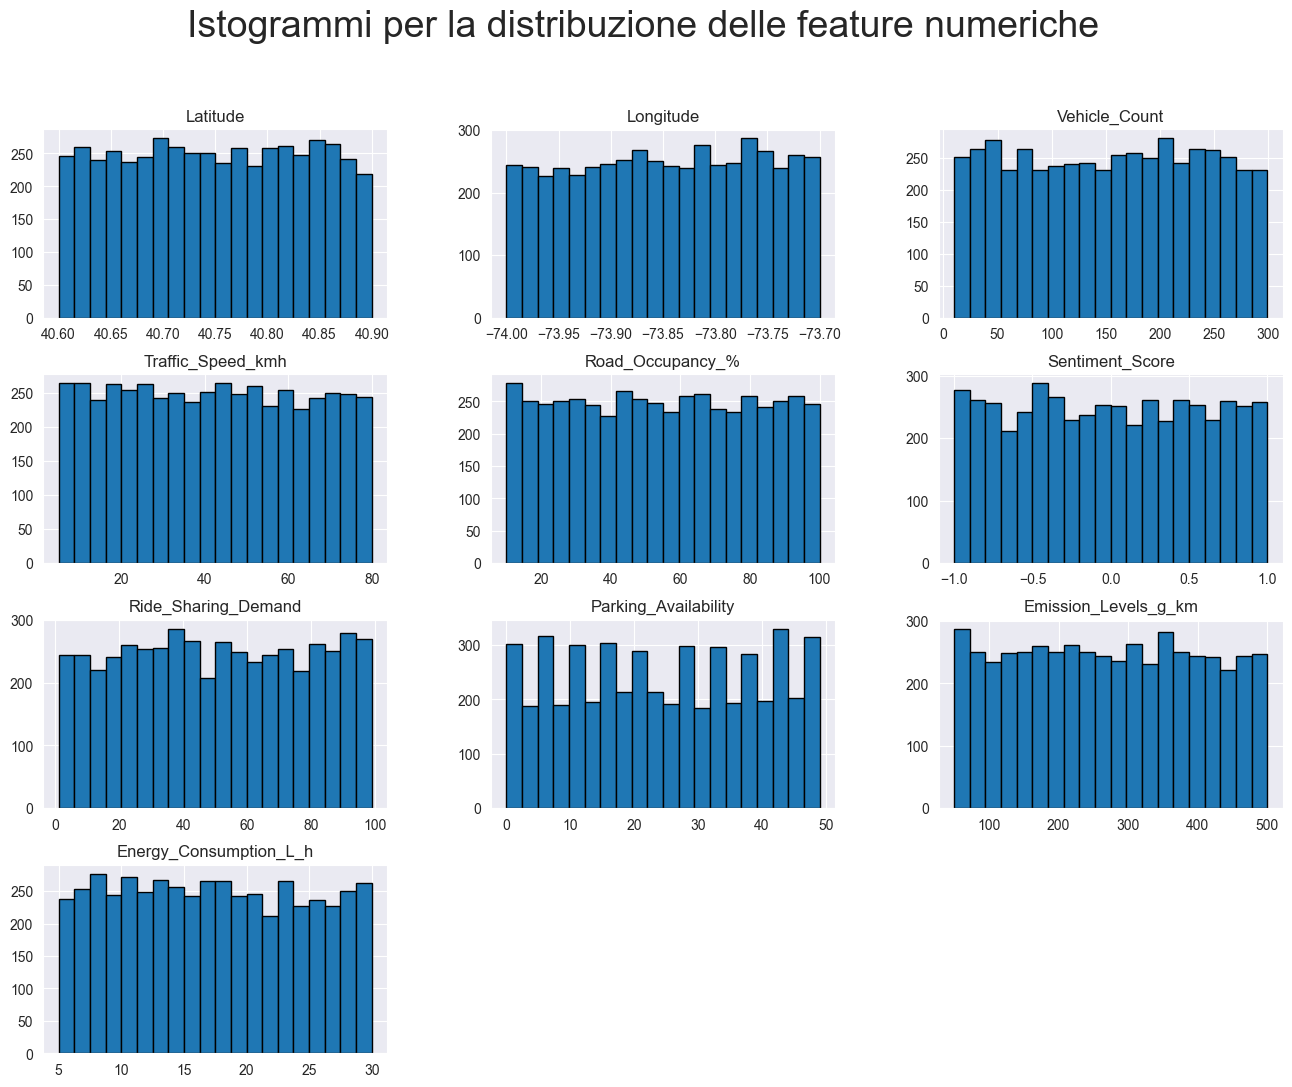

In [6]:
# Istogrammi per la distribuzione delle feature numeriche

# Elenco delle colonne da escludere
columns_to_exclude = ['Traffic_Light_State', 'Weather_Condition', 'Accident_Report' , 'Traffic_Condition']

# Creiamo il subset dei dati senza le feature da escludere
data_subset = dataset.drop(columns=columns_to_exclude)
data_subset.hist(bins=20, figsize=(16, 12), edgecolor='black')
plt.suptitle("Istogrammi per la distribuzione delle feature numeriche", fontsize=27)
plt.show()

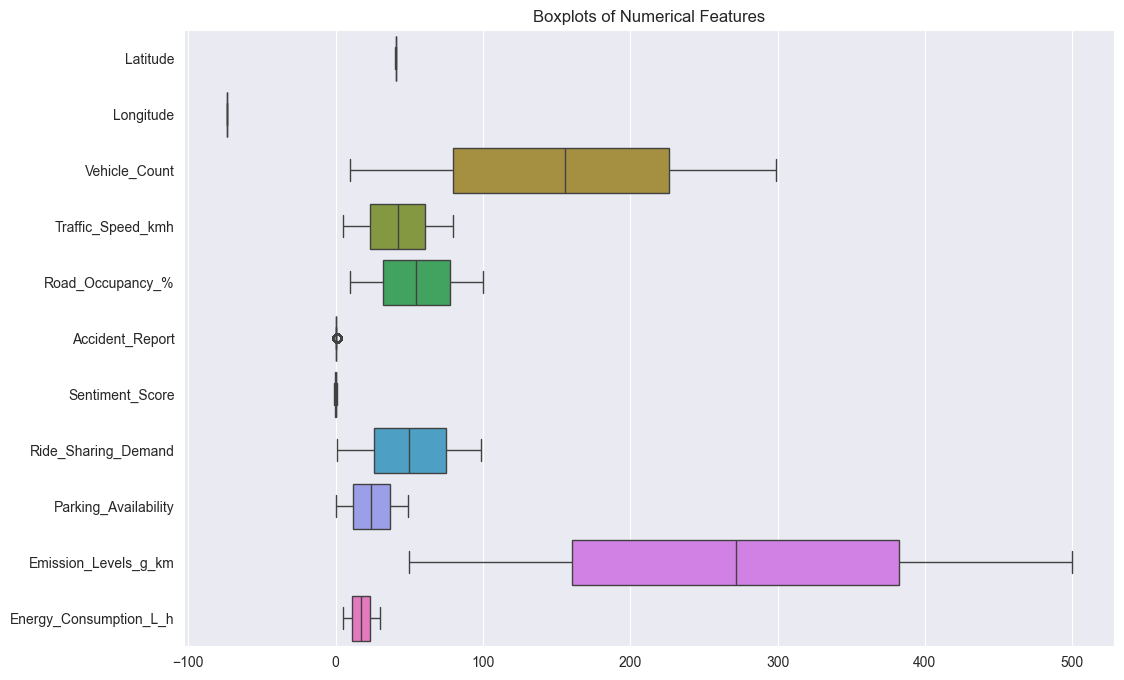

In [7]:
# Boxplot per le feature numeriche
plt.figure(figsize=(12, 8))
sns.boxplot(data=dataset, orient="h") #boxplot serve per vedere eventuali outliers
plt.title("Boxplots of Numerical Features")
plt.show()

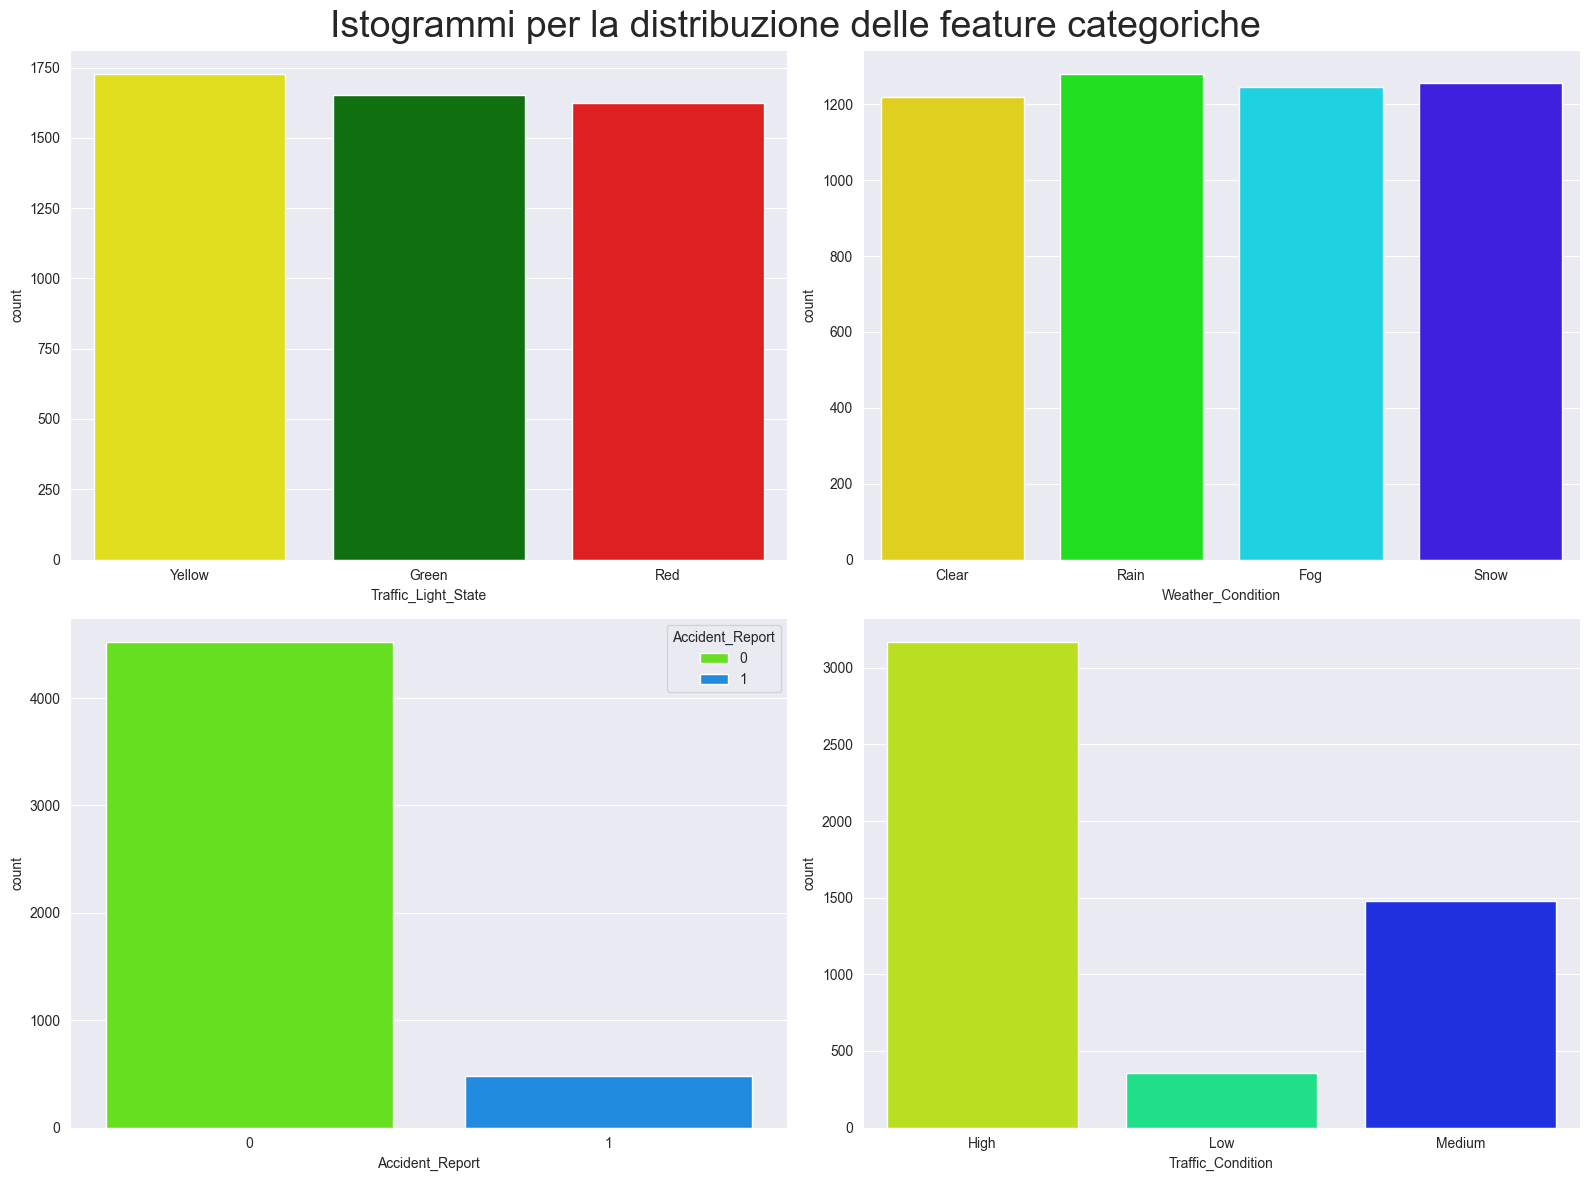

In [8]:
# Istogrammi per le features categoriche
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.countplot(data=dataset, x='Traffic_Light_State', hue='Traffic_Light_State', ax=axes[0, 0], palette={'Red': 'red', 'Yellow': 'yellow', 'Green': 'green'})
sns.countplot(data=dataset, x='Weather_Condition', hue='Weather_Condition', ax=axes[0, 1], palette='gist_rainbow')
sns.countplot(data=dataset, x='Accident_Report', hue='Accident_Report', ax=axes[1, 0], palette='gist_rainbow')
sns.countplot(data=dataset, x='Traffic_Condition', hue='Traffic_Condition', ax=axes[1, 1], palette='gist_rainbow')
plt.suptitle("Istogrammi per la distribuzione delle feature categoriche", fontsize=27)
plt.tight_layout()
plt.show()

## 2 - Preparazione dei dati

In [9]:
#Estrazione info giorno - mese - ora
# Assicuro che 'Timestamp' sia in formato datetime
dataset['Timestamp'] = pd.to_datetime(dataset['Timestamp'])

# Giorno della settimana (0=Lunedì, 6=Domenica)
dataset['DayOfWeek'] = dataset['Timestamp'].dt.dayofweek

# Week-end (1 se sabato o domenica, 0 altrimenti)
dataset['Is_Weekend'] = dataset['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Giorno del mese
dataset['Day'] = dataset['Timestamp'].dt.day

# Mese
dataset['Month'] = dataset['Timestamp'].dt.month

# Ora del giorno
dataset['Hour'] = dataset['Timestamp'].dt.hour

dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,DayOfWeek,Is_Weekend,Day,Month,Hour
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High,4,0,1,3,0
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High,4,0,1,3,0
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High,4,0,1,3,0
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High,4,0,1,3,0
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low,4,0,1,3,0


In [10]:
dataset=dataset.drop(columns=['Month'], axis=1,errors='ignore')

### Label encoding
Per poter calcolare la matrice di correlazione trasformiamo le variabili categoriche in numeriche

In [11]:
# Inizializziamo il LabelEncoder
encoder = LabelEncoder()

# Applichiamo il Label Encoding alle colonne categoriche
# codifica delle categotie in ordine alfabetico ma a noi non va bene per Traffic_Condition

# Mappatura personalizzata per Traffic_Condition
traffic_condition_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

# Applichiamo il mapping
dataset['Traffic_Condition'] = dataset['Traffic_Condition'].map(traffic_condition_mapping)

# Applichiamo il Label Encoding per le altre colonne
columns_to_encode = ['Traffic_Light_State', 'Weather_Condition']
for col in columns_to_encode:
    dataset[col] = encoder.fit_transform(dataset[col])

dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,DayOfWeek,Is_Weekend,Day,Hour
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,2,0,0,-0.609199,2,45,450.760055,19.574337,2,4,0,1,0
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,0,0,0,0.965442,16,1,321.800341,5.385554,2,4,0,1,0
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,0,2,0,0.289660,16,49,231.152655,10.277477,2,4,0,1,0
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,1,1,0,-0.271965,66,10,410.384292,29.243279,2,4,0,1,0
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,1,3,0,-0.797606,3,5,364.466342,16.801459,0,4,0,1,0


In [12]:
# Verifichiamo l'aggiornamento delle colonne
print(f"{dataset.dtypes}\n")

Timestamp                 datetime64[ns]
Latitude                         float64
Longitude                        float64
Vehicle_Count                      int64
Traffic_Speed_kmh                float64
Road_Occupancy_%                 float64
Traffic_Light_State                int64
Weather_Condition                  int64
Accident_Report                    int64
Sentiment_Score                  float64
Ride_Sharing_Demand                int64
Parking_Availability               int64
Emission_Levels_g_km             float64
Energy_Consumption_L_h           float64
Traffic_Condition                  int64
DayOfWeek                          int32
Is_Weekend                         int64
Day                                int32
Hour                               int32
dtype: object



In [13]:
#Calcolo emissioni Co2
# Durata osservazione: 5 minuti = 1/12 ore
tempo_ore = 1 / 12

# Calcolo distanza percorsa: Distanza = Velocità × Tempo
dataset['Distanza_km'] = dataset['Traffic_Speed_kmh'] * tempo_ore

# Calcolo emissioni totali: Emissioni = emissioni specifiche × distanza
dataset['Emission_CO2_total'] = dataset['Emission_Levels_g_km'] * dataset['Distanza_km']

#calcolo consumo energetico totale
# Consumo energetico (in litri) per l’intervallo osservato
dataset['Fuel_Consumed_L'] = dataset['Energy_Consumption_L_h'] * tempo_ore

# (opzionale) conversione litri → MJ (approssimazione: 1 L di benzina ≈ 34.2 MJ)
dataset['Energy_MJ_total'] = dataset['Fuel_Consumed_L'] * 34.2
dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,...,Energy_Consumption_L_h,Traffic_Condition,DayOfWeek,Is_Weekend,Day,Hour,Distanza_km,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,2,0,0,-0.609199,...,19.574337,2,4,0,1,0,4.157786,1874.163951,1.631195,55.786859
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,0,0,0,0.965442,...,5.385554,2,4,0,1,0,1.865330,600.263960,0.448796,15.348828
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,0,2,0,0.289660,...,10.277477,2,4,0,1,0,3.907475,903.223209,0.856456,29.290811
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,1,1,0,-0.271965,...,29.243279,2,4,0,1,0,0.477545,195.976844,2.436940,83.343346
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,1,3,0,-0.797606,...,16.801459,0,4,0,1,0,5.112336,1863.274471,1.400122,47.884157


In [14]:
from sklearn.preprocessing import StandardScaler
df=dataset.copy()
# --- FEATURE TEMPORALI ---
def time_slot(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 24:
        return 'evening'
    else:
        return 'night'

dataset['Time_Slot'] = dataset['Hour'].apply(time_slot)
# --- CATEGORICAL ENCODING ---
categorical_cols = ['Time_Slot']
dataset = pd.get_dummies(dataset, columns=categorical_cols, drop_first=False)

# --- NORMALIZZAZIONE ---
features_to_scale = [
    'Vehicle_Count', 'Road_Occupancy_%',
    'Traffic_Speed_kmh', 'Emission_Levels_g_km',
    'Energy_Consumption_L_h'
]

scaler = MinMaxScaler()
df[[f + '_norm' for f in features_to_scale]] = scaler.fit_transform(df[features_to_scale])


# --- INTERAZIONI ---
dataset['Speed_Occupancy_Interaction'] = df['Traffic_Speed_kmh_norm'] * df['Road_Occupancy_%_norm']
dataset['Emission_Energy_Interaction'] = df['Emission_Levels_g_km_norm'] * df['Energy_Consumption_L_h_norm']
dataset['Congestion_Index'] = 0.4 * df['Vehicle_Count_norm'] + 0.6 * df['Road_Occupancy_%_norm']

dataset=dataset.drop(columns=['Traffic_Speed_kmh_norm','Road_Occupancy_%_norm','Emission_Levels_g_km_norm','Vehicle_Count_norm','Energy_Consumption_L_h_norm'], axis=1,errors='ignore')
dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,...,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Time_Slot_afternoon,Time_Slot_evening,Time_Slot_morning,Time_Slot_night,Speed_Occupancy_Interaction,Emission_Energy_Interaction,Congestion_Index
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,2,0,0,-0.609199,...,1874.163951,1.631195,55.786859,False,False,False,True,0.483204,0.519292,0.754243
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,0,0,0,0.965442,...,600.263960,0.448796,15.348828,False,False,False,True,0.092259,0.009226,0.504586
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,0,2,0,0.289660,...,903.223209,0.856456,29.290811,False,False,False,True,0.451614,0.084924,0.820093
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,1,1,0,-0.271965,...,195.976844,2.436940,83.343346,False,False,False,True,0.002986,0.776827,0.221985
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,1,3,0,-0.797606,...,1863.274471,1.400122,47.884157,False,False,False,True,0.102756,0.329899,0.156801


In [15]:
print(f"{dataset.dtypes}\n")

Timestamp                      datetime64[ns]
Latitude                              float64
Longitude                             float64
Vehicle_Count                           int64
Traffic_Speed_kmh                     float64
Road_Occupancy_%                      float64
Traffic_Light_State                     int64
Weather_Condition                       int64
Accident_Report                         int64
Sentiment_Score                       float64
Ride_Sharing_Demand                     int64
Parking_Availability                    int64
Emission_Levels_g_km                  float64
Energy_Consumption_L_h                float64
Traffic_Condition                       int64
DayOfWeek                               int32
Is_Weekend                              int64
Day                                     int32
Hour                                    int32
Distanza_km                           float64
Emission_CO2_total                    float64
Fuel_Consumed_L                   

In [16]:
dataset.describe()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,...,Is_Weekend,Day,Hour,Distanza_km,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Speed_Occupancy_Interaction,Emission_Energy_Interaction,Congestion_Index
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-03-09 16:17:30,40.749645,-73.847433,153.921200,42.111096,54.748397,1.015000,1.514800,0.096000,-0.005652,...,0.345600,9.187200,11.340800,3.509258,953.609596,1.445270,49.428244,0.244970,0.242429,0.497506
min,2024-03-01 00:00:00,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,0.000000,0.000000,-0.999819,...,0.000000,1.000000,0.000000,0.416899,25.240133,0.416982,14.260793,0.000000,0.000000,0.001389
25%,2024-03-05 08:08:45,40.675403,-73.920281,80.000000,23.195752,32.089653,0.000000,1.000000,0.000000,-0.500154,...,0.000000,5.000000,5.000000,1.932979,372.866989,0.924897,31.631469,0.064253,0.064718,0.339425
50%,2024-03-09 16:17:30,40.748875,-73.846058,156.000000,42.191599,54.657297,1.000000,2.000000,0.000000,-0.010564,...,0.000000,9.000000,11.000000,3.515967,764.954798,1.429483,48.888304,0.181674,0.178111,0.498917
75%,2024-03-14 00:26:15,40.824735,-73.771685,226.000000,60.751760,77.581720,2.000000,3.000000,0.000000,0.500518,...,1.000000,14.000000,17.000000,5.062647,1385.897095,1.959716,67.022297,0.371288,0.369949,0.653731
max,2024-03-18 08:35:00,40.899972,-73.700159,299.000000,79.997556,99.999729,2.000000,3.000000,1.000000,0.999354,...,1.000000,18.000000,23.000000,6.666463,3287.507347,2.499618,85.486935,0.976236,0.991837,0.991525
std,NaN,0.086123,0.086204,83.523342,21.707720,26.145238,0.821773,1.113746,0.294621,0.583790,...,0.475611,5.015535,6.946474,1.808977,711.112975,0.600690,20.543589,0.220252,0.217961,0.212167


## Matrice di correlazione

Matrice di correlazione:



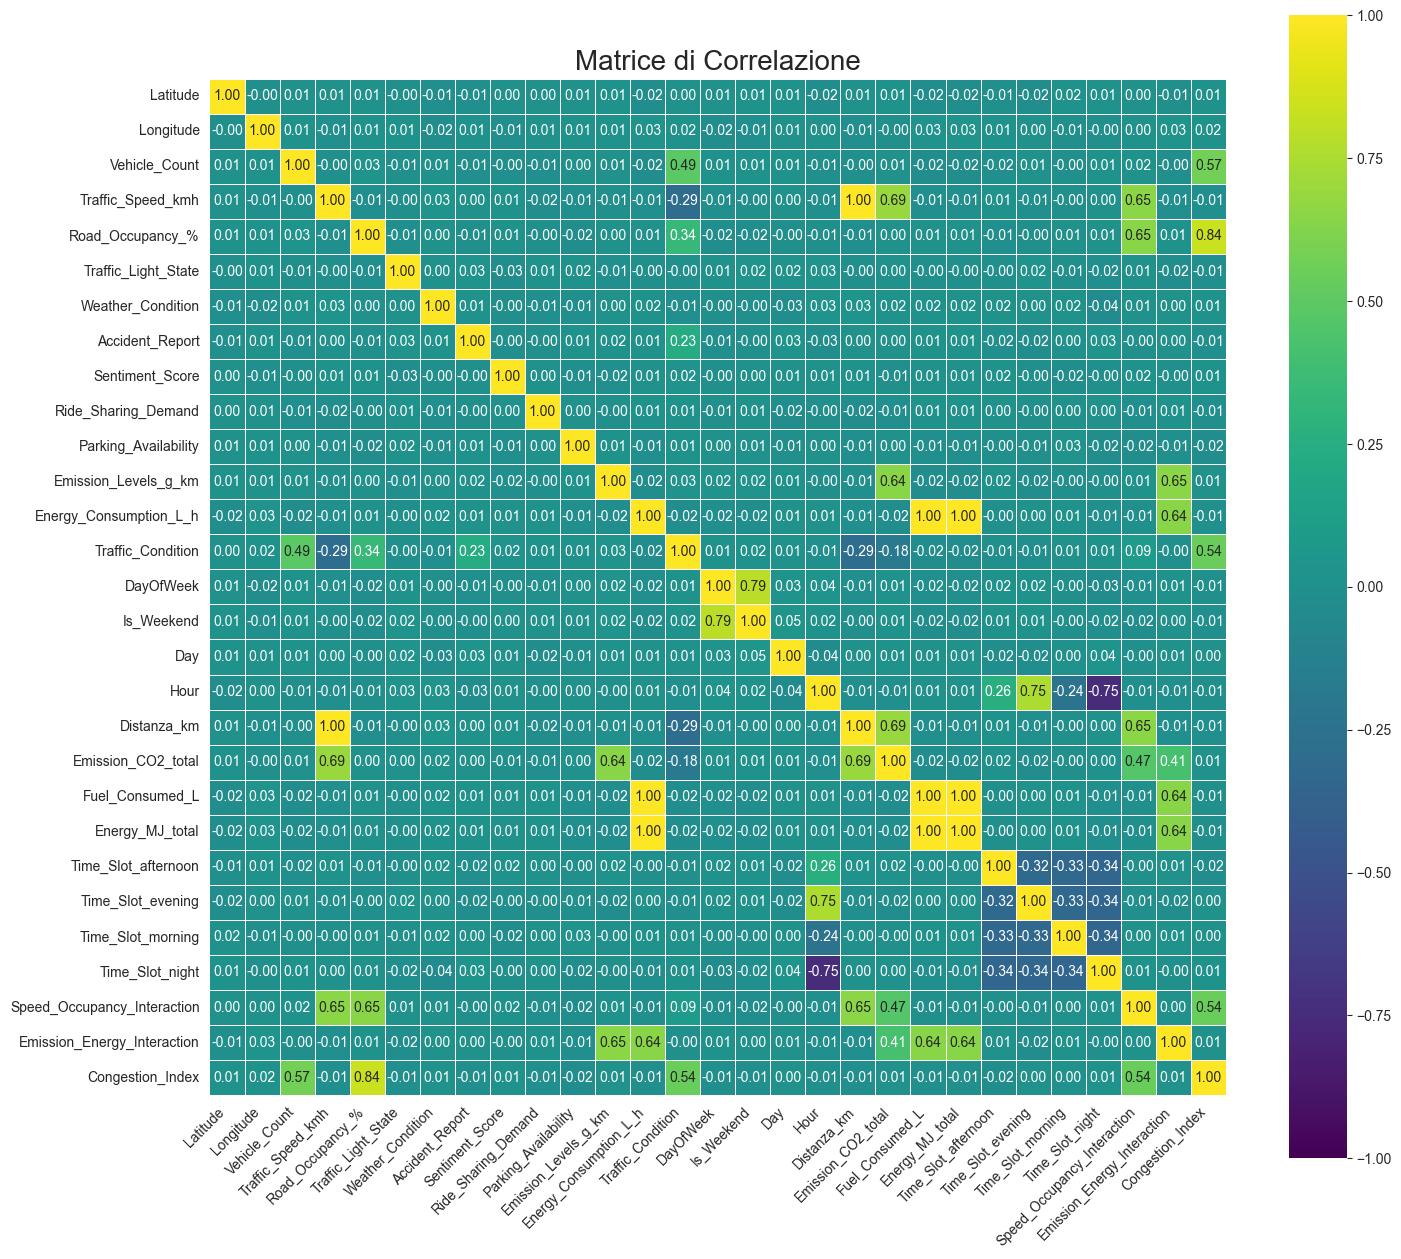

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Matrice di correlazione:\n')
corr_matrix = dataset.corr(numeric_only=True)

plt.figure(figsize=(15, 15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    square=True,
    linewidths=0.5,
    linecolor='white',
    vmax=1,
    vmin=-1,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice di Correlazione", fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
dataset.columns

Index(['Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count',
       'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Traffic_Light_State',
       'Weather_Condition', 'Accident_Report', 'Sentiment_Score',
       'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km',
       'Energy_Consumption_L_h', 'Traffic_Condition', 'DayOfWeek',
       'Is_Weekend', 'Day', 'Hour', 'Distanza_km', 'Emission_CO2_total',
       'Fuel_Consumed_L', 'Energy_MJ_total', 'Time_Slot',
       'Speed_Occupancy_Interaction', 'Emission_Energy_Interaction',
       'Congestion_Index'],
      dtype='object')

## CLASSIFICAZIONE DELLO STATO DEL TRAFFICO

In [18]:
# cancellazione delle feature inutili e di quelle utilizzate nel calcolo delle iterazioni
df1=dataset.copy()
df1=df1.drop(columns=['Sentiment_Score','Ride_Sharing_Demand','Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count',
       'Traffic_Speed_kmh', 'Road_Occupancy_%', 'DayOfWeek', 'Emission_Levels_g_km',
       'Energy_Consumption_L_h', 'Fuel_Consumed_L', 'Distanza_km','Hour'], axis=1,errors='ignore')
df1.head()

,Traffic_Light_State,Weather_Condition,Accident_Report,Parking_Availability,Traffic_Condition,Is_Weekend,Day,Emission_CO2_total,Energy_MJ_total,Time_Slot_afternoon,Time_Slot_evening,Time_Slot_morning,Time_Slot_night,Speed_Occupancy_Interaction,Emission_Energy_Interaction,Congestion_Index
0,2,0,0,45,2,0,1,1874.163951,55.786859,False,False,False,True,0.483204,0.519292,0.754243
1,0,0,0,1,2,0,1,600.263960,15.348828,False,False,False,True,0.092259,0.009226,0.504586
2,0,2,0,49,2,0,1,903.223209,29.290811,False,False,False,True,0.451614,0.084924,0.820093
3,1,1,0,10,2,0,1,195.976844,83.343346,False,False,False,True,0.002986,0.776827,0.221985
4,1,3,0,5,0,0,1,1863.274471,47.884157,False,False,False,True,0.102756,0.329899,0.156801


In [19]:
df1.columns

Index(['Traffic_Light_State', 'Weather_Condition', 'Accident_Report',
       'Parking_Availability', 'Traffic_Condition', 'Is_Weekend', 'Day',
       'Emission_CO2_total', 'Energy_MJ_total', 'Time_Slot_afternoon',
       'Time_Slot_evening', 'Time_Slot_morning', 'Time_Slot_night',
       'Speed_Occupancy_Interaction', 'Emission_Energy_Interaction',
       'Congestion_Index'],
      dtype='object')

Classification Report:
              precision    recall  f1-score   support

         Low       0.76      0.52      0.61        60
      Medium       0.74      0.64      0.69       307
        High       0.85      0.94      0.89       633

    accuracy                           0.82      1000
   macro avg       0.78      0.70      0.73      1000
weighted avg       0.81      0.82      0.81      1000



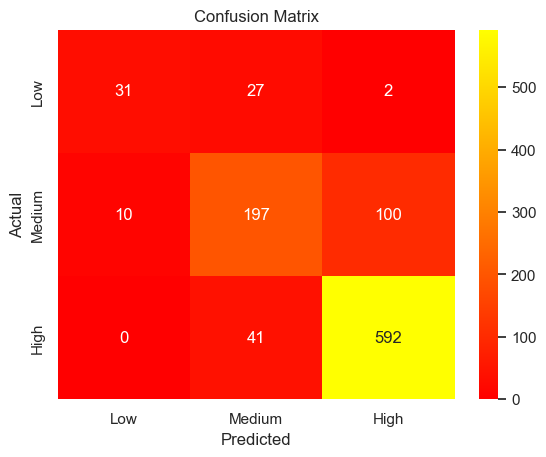

In [49]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Separazione delle variabili
X = df1.drop("Traffic_Condition", axis=1)  # Tutte le colonne tranne target
y = df1["Traffic_Condition"]  # Target

# Divisione in train, validation e test
# 1. Split iniziale: 80% per training+validation, 20% per test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Split secondario: 75% di X_temp per training, 25% per validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
# 0.25 × 0.8 = 0.20 → quindi: 60% train, 20% val, 20% test

#Inizializzazione e addestramento Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

#Predizione e valutazione
y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))

#Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='autumn', xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [50]:
print("Train accuracy:", clf.score(X_train, y_train))
print("Test accuracy:", clf.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.82


In [51]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kfold = KFold(n_splits=10, random_state=11, shuffle=True)

cv_scores = cross_val_score(clf, X, y, cv=kfold)
print(f"Cross-Validation Accuracy: {cv_scores}")
print(f'Precisione media: {cv_scores.mean():.2%}')
print(f'Deviazione standard: {cv_scores.std():.2%}')

Cross-Validation Accuracy: [0.85  0.834 0.824 0.824 0.836 0.842 0.854 0.838 0.824 0.85 ]
Precisione media: 83.76%
Deviazione standard: 1.08%


Vediamo la profondità dell'albero per verificare se non è overfittato

 Analisi della Random Forest
- Numero di alberi nella foresta: 100
- Profondità media: 21.18
- Numero medio di foglie: 491.91
- Profondità massima: 26
- Profondità minima: 17


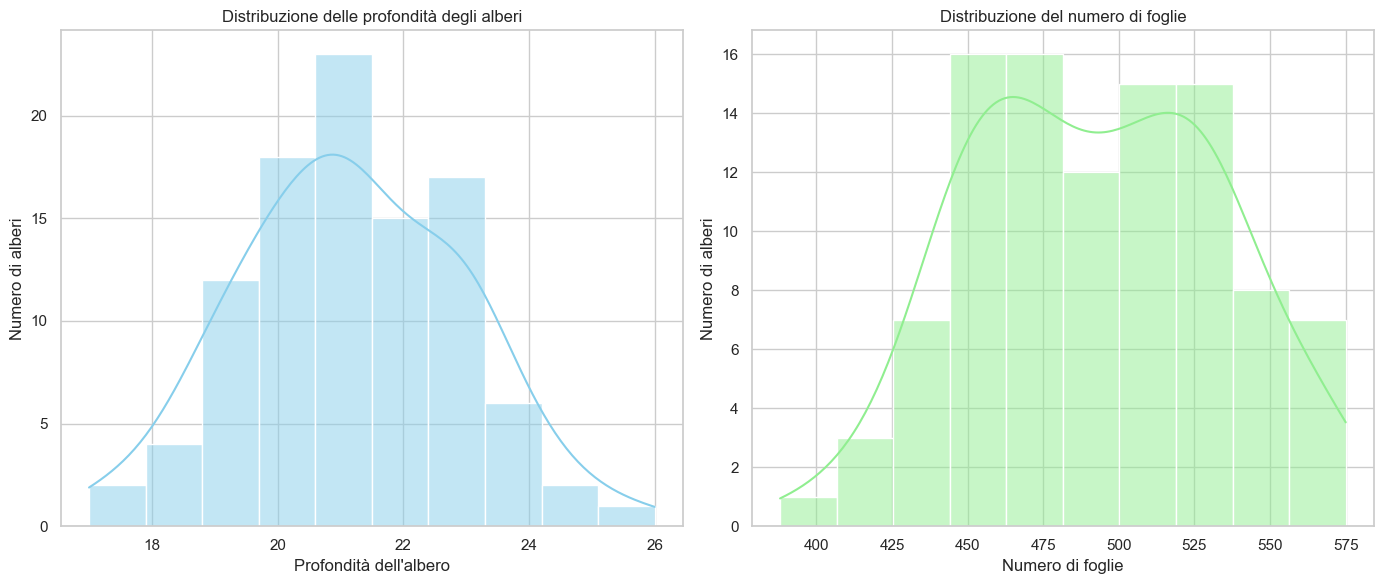

In [52]:
# Calcolo statistiche globali sugli alberi della foresta
depths = [tree.get_depth() for tree in clf.estimators_]
leaves = [tree.get_n_leaves() for tree in clf.estimators_]

print(" Analisi della Random Forest")
print(f"- Numero di alberi nella foresta: {len(clf.estimators_)}")
print(f"- Profondità media: {sum(depths) / len(depths):.2f}")
print(f"- Numero medio di foglie: {sum(leaves) / len(leaves):.2f}")
print(f"- Profondità massima: {max(depths)}")
print(f"- Profondità minima: {min(depths)}")

# Imposta lo stile del grafico
sns.set_theme(style="whitegrid")

# Crea la figura con due sottografici
plt.figure(figsize=(14, 6))

# Distribuzione della profondità
plt.subplot(1, 2, 1)
sns.histplot(depths, bins=10, kde=True, color="skyblue")
plt.title("Distribuzione delle profondità degli alberi")
plt.xlabel("Profondità dell'albero")
plt.ylabel("Numero di alberi")

# Distribuzione del numero di foglie
plt.subplot(1, 2, 2)
sns.histplot(leaves, bins=10, kde=True, color="lightgreen")
plt.title("Distribuzione del numero di foglie")
plt.xlabel("Numero di foglie")
plt.ylabel("Numero di alberi")

# Mostra i grafici
plt.tight_layout()
plt.show()

|--- Emission_CO2_total <= 503.43
|   |--- Speed_Occupancy_Interaction <= 0.07
|   |   |--- Emission_Energy_Interaction <= 0.25
|   |   |   |--- Emission_CO2_total <= 369.76
|   |   |   |   |--- Emission_CO2_total <= 222.49
|   |   |   |   |   |--- Congestion_Index <= 0.12
|   |   |   |   |   |   |--- Day <= 4.50
|   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |--- Day >  4.50
|   |   |   |   |   |   |   |--- class: 2.0
|   |   |   |   |   |--- Congestion_Index >  0.12
|   |   |   |   |   |   |--- Is_Weekend <= 0.50
|   |   |   |   |   |   |   |--- Speed_Occupancy_Interaction <= 0.01
|   |   |   |   |   |   |   |   |--- Speed_Occupancy_Interaction <= 0.01
|   |   |   |   |   |   |   |   |   |--- class: 2.0
|   |   |   |   |   |   |   |   |--- Speed_Occupancy_Interaction >  0.01
|   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- Speed_Occupancy_Interaction >  0.01
|   |   |   |   |   |   |   |   |--- class: 2.0
|   |   |   |   |   | 

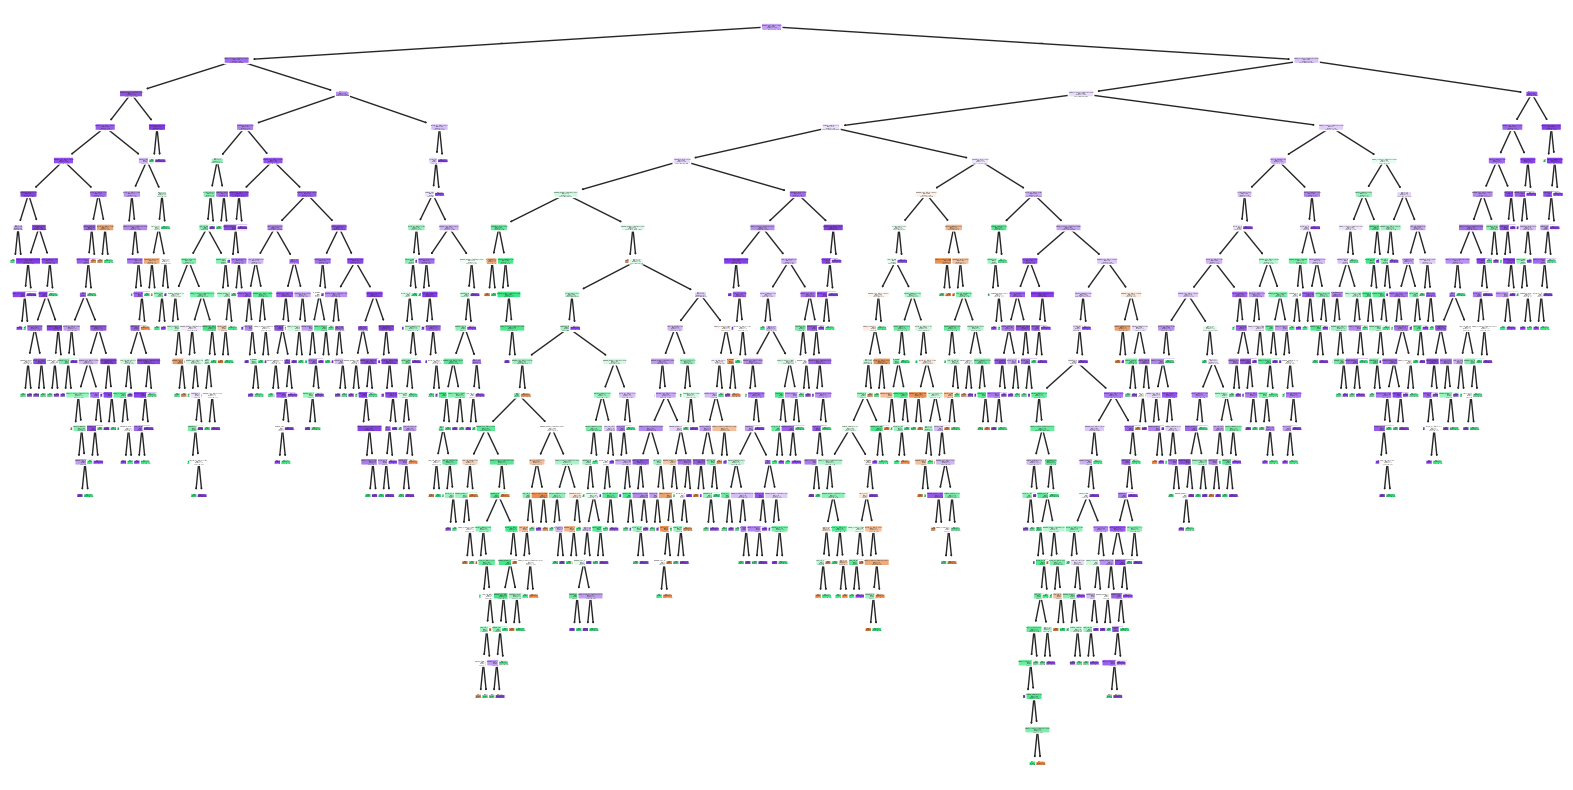

In [53]:
# Prendi un singolo albero
tree = clf.estimators_[0]

# Poi usa plot_tree o export_text come sopra su 'tree'
from sklearn.tree import export_text, plot_tree
print(export_text(tree, feature_names=list(X.columns)))

import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns, filled=True, rounded=True)
plt.show()


Cerchiamo di ridurre l'overfitting andando a valutare le feature più importati. Dopo aver ottenuto la classifica delle feature più rilevanti, il primo passo è valutare se tutte le feature sono realmente necessarie.

FEATURE IMPORTANCE

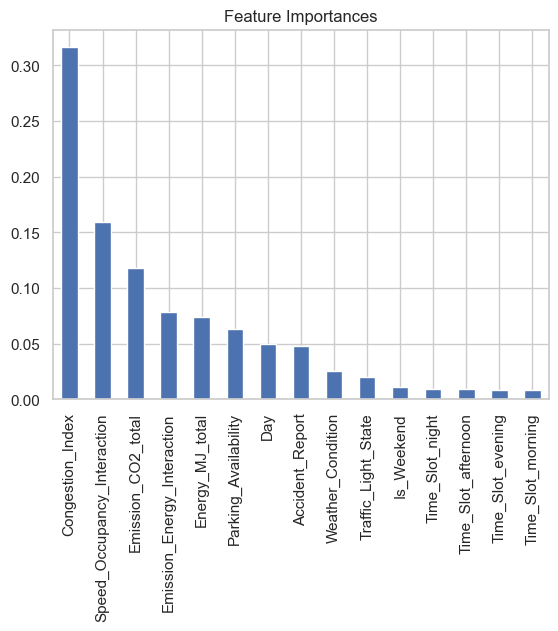

In [54]:
importances = clf.feature_importances_
features = X.columns
forest_importances = pd.Series(importances, index=features).sort_values(ascending=False)

forest_importances.plot(kind='bar')
plt.title("Feature Importances")
plt.show()

Selezioniamo le feature più importanti (come si evince dal grafico) in modo da ridurre la complessità del modello.

Feature selezionate da RFE:
Index(['Traffic_Light_State', 'Weather_Condition', 'Accident_Report',
       'Parking_Availability', 'Day', 'Emission_CO2_total', 'Energy_MJ_total',
       'Speed_Occupancy_Interaction', 'Emission_Energy_Interaction',
       'Congestion_Index'],
      dtype='object')
              precision    recall  f1-score   support

           0       0.83      0.74      0.79        94
           1       0.75      0.69      0.72       439
           2       0.88      0.92      0.90       967

    accuracy                           0.84      1500
   macro avg       0.82      0.79      0.80      1500
weighted avg       0.84      0.84      0.84      1500



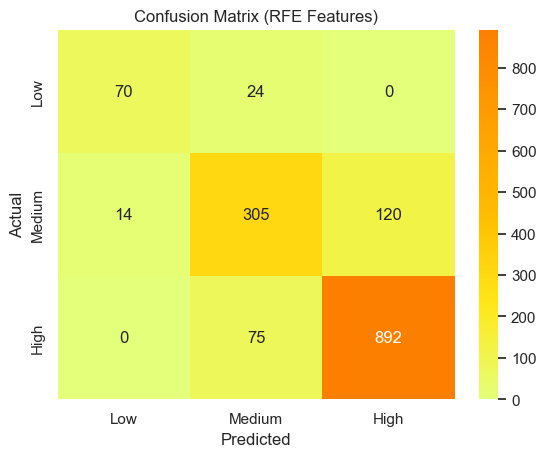

In [42]:
from sklearn.feature_selection import RFE

# Selezione delle feature su dati di training
selector = RFE(estimator=clf, n_features_to_select=10, step=1)
selector = selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.support_]
print("Feature selezionate da RFE:")
print(selected_features)

# Applica la selezione alle stesse colonne in train e test
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# Training e valutazione
clf_selected = RandomForestClassifier(random_state=42)
clf_selected.fit(X_train_sel, y_train_sel := y_train)  # y_train_sel è solo alias per chiarezza

y_pred_sel = clf_selected.predict(X_test_sel)
print(classification_report(y_test_sel := y_test, y_pred_sel))

# Matrice di confusione corretta
new_cm = confusion_matrix(y_test_sel, y_pred_sel)
sns.heatmap(new_cm, annot=True, fmt='d', cmap='Wistia',
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (RFE Features)")
plt.show()


In [55]:
print("Train accuracy:", clf_selected.score(X_train_sel, y_train_sel))
print("Test accuracy:", clf_selected.score(X_test_sel, y_test_sel))

Train accuracy: 1.0
Test accuracy: 0.8446666666666667


Abbiamo migliorato l'overfitting ma non è ancora ideale quindi adottiamo la strada Hyperparamiter optimization.

In [56]:
from sklearn.model_selection import RandomizedSearchCV

# Parametri da ottimizzare
param_grid = {
    'n_estimators': [100, 200, 300],          # numero di alberi
    'max_depth': [10, 20, 30, None],          # profondità massima
    'min_samples_split': [2, 5, 10],          # minimi campioni per split
    'min_samples_leaf': [1, 2, 4],            # minimi campioni in foglia
    }

grid_search = RandomizedSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_sel, y_train_sel)

print("Migliori parametri:", grid_search.best_params_)
print("Score migliore:", grid_search.best_score_)

Migliori parametri: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
Score migliore: 0.8422857142857143


Accuracy: 0.8393333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.61      0.70        94
           1       0.74      0.70      0.72       439
           2       0.88      0.93      0.90       967

    accuracy                           0.84      1500
   macro avg       0.82      0.74      0.77      1500
weighted avg       0.84      0.84      0.84      1500



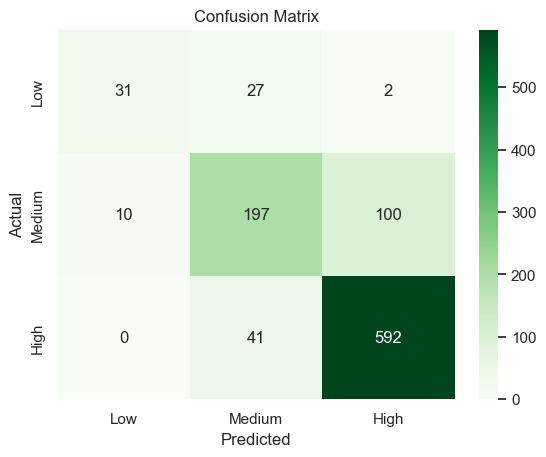

In [59]:
from sklearn.metrics import classification_report, accuracy_score

# Modello con parametri ottimali trovati
clf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Addestramento
clf_best.fit(X_train_sel, y_train_sel)

# Valutazione
y_pred_final = clf_best.predict(X_test_sel)

print("Accuracy:", accuracy_score(y_test_sel, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test_sel, y_pred_final))

# Matrice di confusione
final_cm = confusion_matrix(y_test_sel, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [60]:
print("Train accuracy:", clf_best.score(X_train_sel, y_train_sel))
print("Test accuracy:", clf_best.score(X_test_sel, y_test_sel))

Train accuracy: 0.9420952380952381
Test accuracy: 0.8393333333333334


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kfold = KFold(n_splits=10, random_state=11, shuffle=True)

cv_scores = cross_val_score(clf_best, X, y, cv=kfold)
print(f"Cross-Validation Accuracy: {cv_scores}")
print(f'Precisione media: {cv_scores.mean():.2%}')
print(f'Deviazione standard: {cv_scores.std():.2%}')

 Analisi della Random Forest con tutte le correzioni adottate
- Numero di alberi nella foresta: 100
- Profondità media: 18.77
- Numero medio di foglie: 213.23
- Profondità massima: 20
- Profondità minima: 15


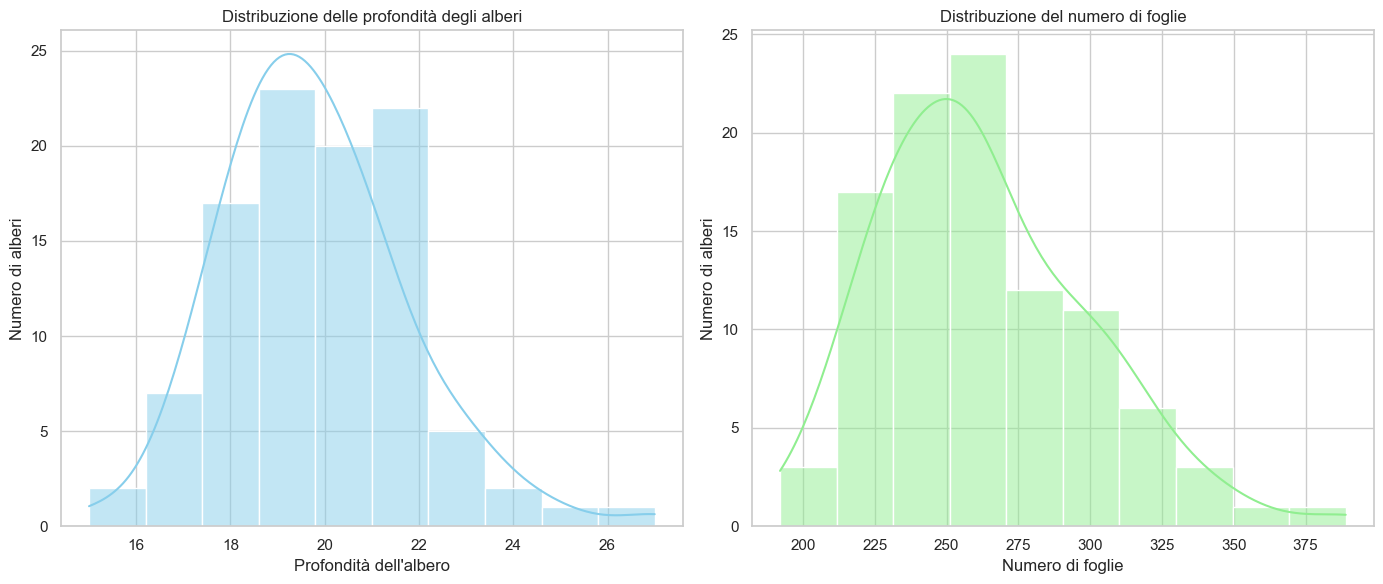

In [206]:
# Calcolo statistiche globali sugli alberi della foresta
new_depths = [tree.get_depth() for tree in clf_best.estimators_]
new_leaves = [tree.get_n_leaves() for tree in clf_best.estimators_]

print(" Analisi della Random Forest con tutte le correzioni adottate")
print(f"- Numero di alberi nella foresta: {len(clf_best.estimators_)}")
print(f"- Profondità media: {sum(new_depths) / len(new_depths):.2f}")
print(f"- Numero medio di foglie: {sum(new_leaves) / len(new_leaves):.2f}")
print(f"- Profondità massima: {max(new_depths)}")
print(f"- Profondità minima: {min(new_depths)}")

# Imposta lo stile del grafico
sns.set_theme(style="whitegrid")

# Crea la figura con due sottografici
plt.figure(figsize=(14, 6))

# Distribuzione della profondità
plt.subplot(1, 2, 1)
sns.histplot(depths, bins=10, kde=True, color="skyblue")
plt.title("Distribuzione delle profondità degli alberi")
plt.xlabel("Profondità dell'albero")
plt.ylabel("Numero di alberi")

# Distribuzione del numero di foglie
plt.subplot(1, 2, 2)
sns.histplot(leaves, bins=10, kde=True, color="lightgreen")
plt.title("Distribuzione del numero di foglie")
plt.xlabel("Numero di foglie")
plt.ylabel("Numero di alberi")

# Mostra i grafici
plt.tight_layout()
plt.show()

|--- Traffic_Speed_kmh <= 20.00
|   |--- class: 2.0
|--- Traffic_Speed_kmh >  20.00
|   |--- Vehicle_Count <= 200.50
|   |   |--- Congestion_Index <= 0.60
|   |   |   |--- Congestion_Index <= 0.33
|   |   |   |   |--- Congestion_Index <= 0.15
|   |   |   |   |   |--- Traffic_Speed_kmh <= 37.16
|   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |--- Traffic_Speed_kmh >  37.16
|   |   |   |   |   |   |--- Traffic_Speed_kmh <= 76.04
|   |   |   |   |   |   |   |--- Traffic_Speed_kmh <= 57.36
|   |   |   |   |   |   |   |   |--- Congestion_Index <= 0.04
|   |   |   |   |   |   |   |   |   |--- Vehicle_Count <= 24.00
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |   |--- Vehicle_Count >  24.00
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |--- Congestion_Index >  0.04
|   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |--- Traffic_Speed_kmh >  57.36
|   |   |   |   |   |

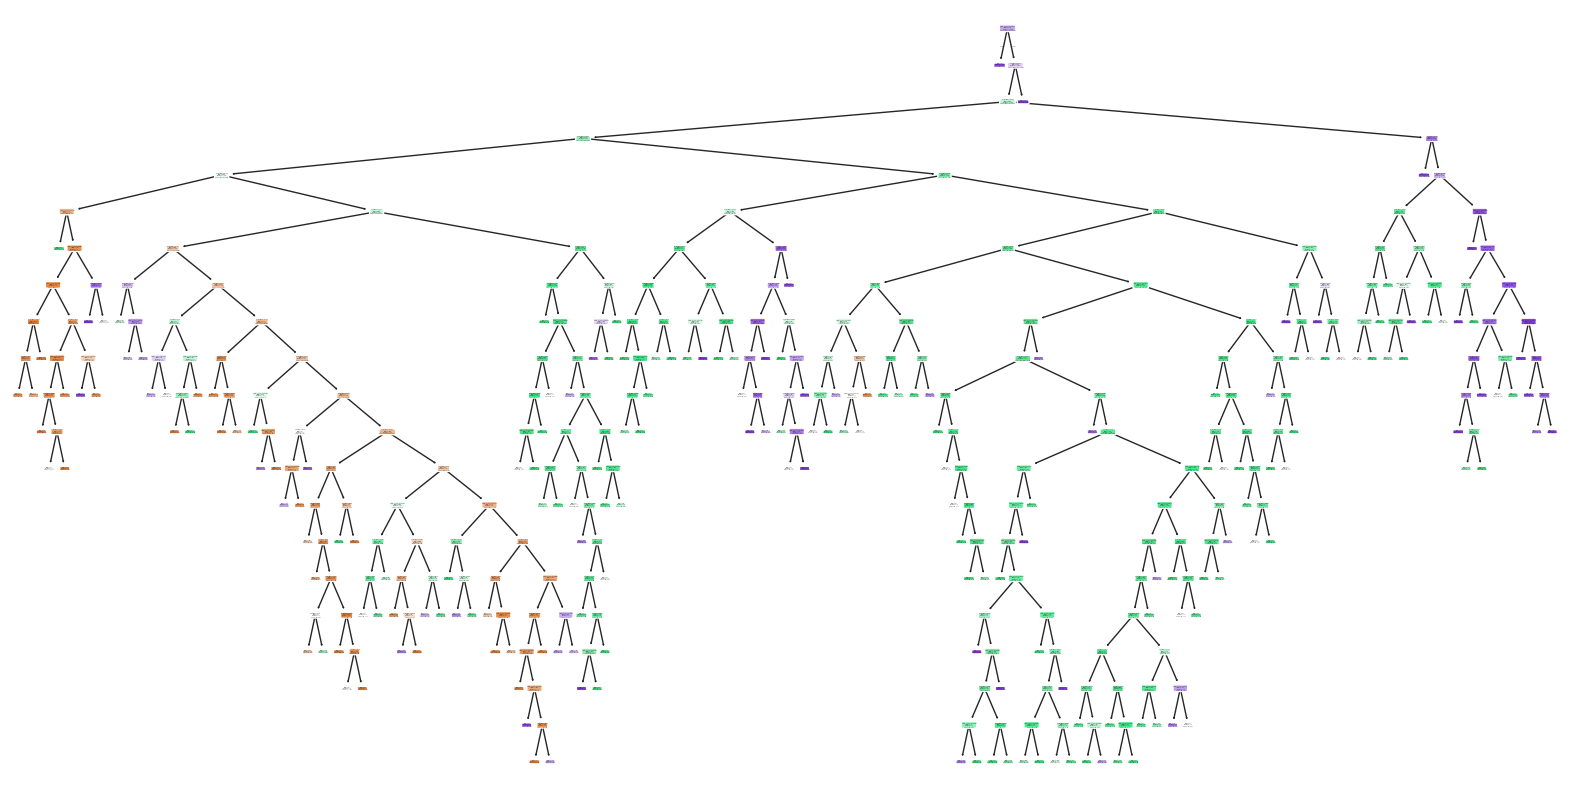

In [207]:
# Prendi un singolo albero
tree_best = clf_best.estimators_[0]

# Poi usa plot_tree o export_text come sopra su 'tree'
from sklearn.tree import export_text, plot_tree
print(export_text(tree_best, feature_names=list(X_train_sel.columns)))

import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(tree_best, feature_names=X.columns, filled=True, rounded=True)
plt.show()

## CURVA AUC-ROC
La curva ROC AUC multiclasse è utile per visualizzare come il modello distingue tra ciascuna classe (Low, Medium, High).  La curva ROC AUC si calcola esclusivamente sui dati di test.

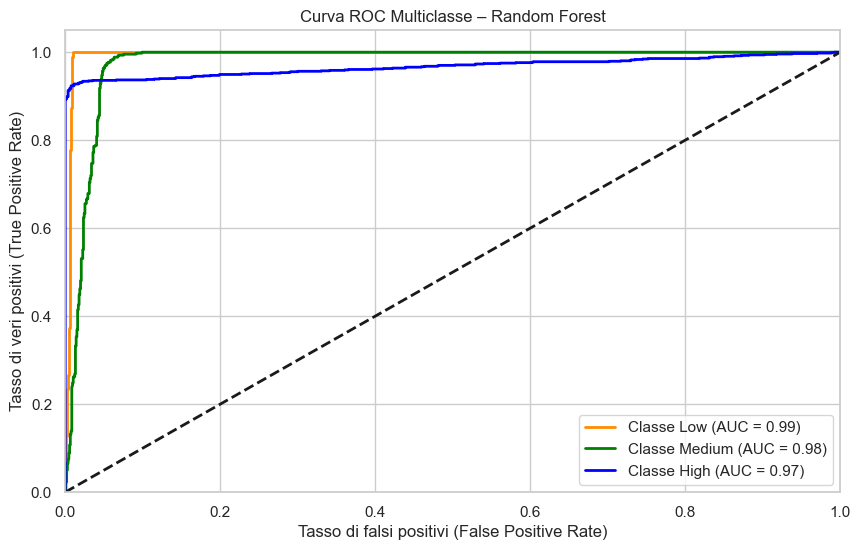

In [208]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt
from itertools import cycle

#0 (Low), 1 (Medium), 2 (High)
y_bin = label_binarize(y_test_sel, classes=[0, 1, 2])
n_classes = y_bin.shape[1]

# Predizione delle probabilità
y_score = clf_best.predict_proba(X_test_sel)

# Calcolo curve ROC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Colori per ogni classe
colors = cycle(['darkorange', 'green', 'blue'])
class_names = ['Low', 'Medium', 'High']

# Plot
plt.figure(figsize=(10, 6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Classe {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasso di falsi positivi (False Positive Rate)')
plt.ylabel('Tasso di veri positivi (True Positive Rate)')
plt.title('Curva ROC Multiclasse – Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Un valore di AUC (Area Under the Curve) rappresenta la capacità di un modello di classificazione di distinguere tra le classi. In particolare, un AUC di 1.0 indica un modello perfetto. Nel nostro caso:

AUC = 0.99 per la classe Low → il modello distingue quasi perfettamente tra "Low" e le altre classi.

AUC = 0.98 per la classe Medium → il modello è in grado di distinguere quasi sempre la classe Medium dalle altre classi.

AUC = 0.97 per la classe High → il modello ha un'ottima capacità di distinguere High, ma non perfetta come nel caso di AUC = 1.

L'AUC per ogni classe nel nostro caso è molto vicino al valore massimo di 1, il che indica che il modello sta facendo un ottimo lavoro nel classificare i dati.

## Previsione sullo stato del traffico

In [209]:
# Dizionario etichette
etichetta = {0: "Low", 1: "Medium", 2: "High"}

# Esempi di nuovi dati (uno per stato)
# Nuovo dato come DataFrame (deve avere le stesse colonne di X_selected)
nuovi_dati = pd.DataFrame([
    {'Traffic_Speed_kmh': 60.0, 'Vehicle_Count': 20, 'Congestion_Index': 0.10},
    {'Traffic_Speed_kmh': 40.0, 'Vehicle_Count': 80, 'Congestion_Index': 0.45},
    {'Traffic_Speed_kmh': 20.0, 'Vehicle_Count': 120, 'Congestion_Index': 0.65}
])

# Predizione e probabilità per ogni riga
for i, row in nuovi_dati.iterrows():
    input_df = pd.DataFrame([row])
    prediction = clf_best.predict(input_df)[0]
    probs = clf_best.predict_proba(input_df)[0]
    stato_traffico = etichetta[prediction]

    print("Dati in ingresso:", dict(row))
    print("Stato del traffico previsto:", stato_traffico)
    print("Probabilità:")
    for j, p in enumerate(probs):
        print(f" - {etichetta[j]}: {p:.2%}")

Dati in ingresso: {'Traffic_Speed_kmh': np.float64(60.0), 'Vehicle_Count': np.float64(20.0), 'Congestion_Index': np.float64(0.1)}
Stato del traffico previsto: Low
Probabilità:
 - Low: 82.85%
 - Medium: 7.13%
 - High: 10.02%
Dati in ingresso: {'Traffic_Speed_kmh': np.float64(40.0), 'Vehicle_Count': np.float64(80.0), 'Congestion_Index': np.float64(0.45)}
Stato del traffico previsto: Medium
Probabilità:
 - Low: 1.33%
 - Medium: 81.62%
 - High: 17.05%
Dati in ingresso: {'Traffic_Speed_kmh': np.float64(20.0), 'Vehicle_Count': np.float64(120.0), 'Congestion_Index': np.float64(0.65)}
Stato del traffico previsto: High
Probabilità:
 - Low: 0.00%
 - Medium: 1.73%
 - High: 98.27%


TASK 2

In [ ]:
df2=dataset.copy()
# --- NUMERICAL SCALING ---
# Seleziono tutte le colonne numeriche da scalare
numerical_cols = [
    'Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh',
    'Road_Occupancy_%', 'Sentiment_Score', 'Ride_Sharing_Demand',
    'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h',
    'DayOfWeek', 'Day', 'Month', 'Hour', 'Distanza_km', 'Emission_CO2_total',
    'Fuel_Consumed_L', 'Energy_MJ_total', 'Speed_Occupancy_Interaction',
    'Emission_Energy_Interaction', 'Congestion_Index'
]

# Applica lo scaling
scaler = StandardScaler()
df2[numerical_cols] = scaler.fit_transform(df2[numerical_cols])